In [ ]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from facenet_pytorch import MTCNN
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score
import numpy as np

In [3]:
class AlignedFaceDataset(Dataset):
    """
    Custom PyTorch Dataset that applies MTCNN face alignment on the fly.
    For larger datasets, it is highly recommended to run this alignment 
    once and save the images to disk to speed up training.
    """
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root_dir)
        self.transform = transform
        #initialize MTCNN for landmark detection (extracting eyes, nose, mouth)
        self.mtcnn = MTCNN(keep_all=False, select_largest=True, device='cuda' if torch.cuda.is_available() else 'cpu')

    def align_face(self, image):
        """
        Calculates the displacement angle using left and right eye coordinates 
        and rotates the picture for final alignment as described in the paper.
        """
        try:
            boxes, probs, landmarks = self.mtcnn.detect(image, landmarks=True)
            if landmarks is not None:
                #0: left eye, 1: right eye
                left_eye = landmarks[0][0]
                right_eye = landmarks[0][1]
                
                #angle for rotation
                dy = right_eye[1] - left_eye[1]
                dx = right_eye[0] - left_eye[0]
                angle = math.degrees(math.atan2(dy, dx))
                
                #rotated image to align eyes horizontally
                aligned_img = image.rotate(angle, resample=Image.BICUBIC)
                #cropped the face using the bounding box
                box = boxes[0]
                aligned_img = aligned_img.crop((box[0], box[1], box[2], box[3]))
                return aligned_img
        except Exception as e:
            pass 
            
        return image

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img = self.align_face(img)
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

2. Data Preparation & Loading

In [4]:
#normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

DATA_DIR = './dataset' 

train_dataset = AlignedFaceDataset(os.path.join(DATA_DIR, 'train'), transform=transform)
val_dataset = AlignedFaceDataset(os.path.join(DATA_DIR, 'valid'), transform=transform)
test_dataset = AlignedFaceDataset(os.path.join(DATA_DIR, 'test'), transform=transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

/home/sapien/documents/dev/projects/asd-alignment/.venv/lib/python3.12/site-packages/facenet_pytorch/models/mtcnn.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_

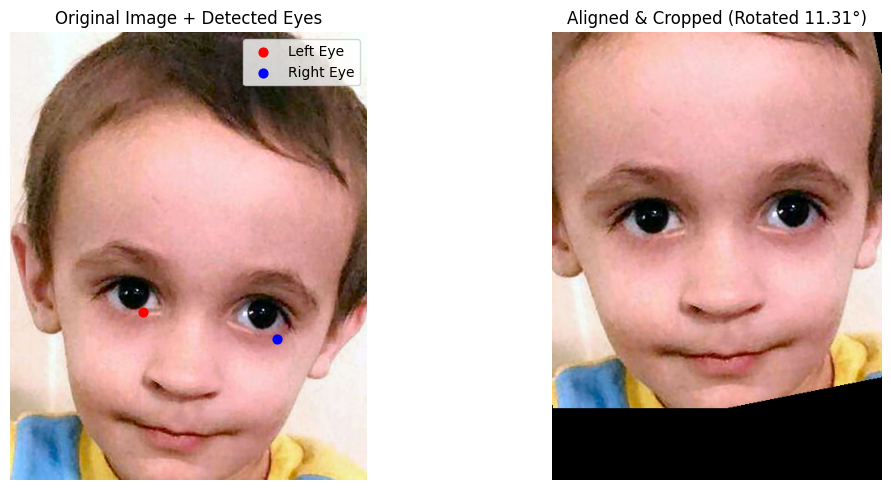

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn = MTCNN(keep_all=False, select_largest=True, device=device)
def visualize_alignment(image_path):
    """
    Loads an image, runs MTCNN to find facial landmarks, calculates the 
    displacement angle between the eyes, and plots the before/after results.
    """
    img = Image.open(image_path).convert('RGB')
    
    boxes, probs, landmarks = mtcnn.detect(img, landmarks=True)
    
    if landmarks is None:
        print(f"No face detected in {image_path}!")
        return
        
    left_eye = landmarks[0][0]
    right_eye = landmarks[0][1]
    
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = math.degrees(math.atan2(dy, dx))
    
    aligned_img = img.rotate(angle, resample=Image.BICUBIC)
    
    box = boxes[0]
    aligned_img = aligned_img.crop((box[0], box[1], box[2], box[3]))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(img)
    axes[0].scatter(left_eye[0], left_eye[1], color='red', s=40, label='Left Eye')
    axes[0].scatter(right_eye[0], right_eye[1], color='blue', s=40, label='Right Eye')
    axes[0].set_title("Original Image + Detected Eyes")
    axes[0].axis('off')
    axes[0].legend()
    axes[1].imshow(aligned_img)
    axes[1].set_title(f"Aligned & Cropped (Rotated {angle:.2f}°)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_alignment('./dataset/train/Autistic/0001.jpg')

3. Model Architecture (ResNet50)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1) 
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

4. Training and Evaluation Loop

In [6]:
EPOCHS = 25 
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        
    epoch_loss = running_loss / len(train_dataset)
    
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    val_loss = val_loss / len(val_dataset)
    val_acc = accuracy_score(all_labels, all_preds)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/25 | Train Loss: 0.4632 | Val Loss: 0.1872 | Val Acc: 0.9625
Epoch 2/25 | Train Loss: 0.1766 | Val Loss: 0.1673 | Val Acc: 0.9375
Epoch 3/25 | Train Loss: 0.1018 | Val Loss: 0.1794 | Val Acc: 0.9000
Epoch 4/25 | Train Loss: 0.0583 | Val Loss: 0.1338 | Val Acc: 0.9250
Epoch 5/25 | Train Loss: 0.0321 | Val Loss: 0.1418 | Val Acc: 0.9375
Epoch 6/25 | Train Loss: 0.0164 | Val Loss: 0.1532 | Val Acc: 0.9625
Epoch 7/25 | Train Loss: 0.0427 | Val Loss: 0.2713 | Val Acc: 0.9000
Epoch 8/25 | Train Loss: 0.0467 | Val Loss: 0.2691 | Val Acc: 0.9000
Epoch 9/25 | Train Loss: 0.0446 | Val Loss: 0.1738 | Val Acc: 0.9500
Epoch 10/25 | Train Loss: 0.0348 | Val Loss: 0.2988 | Val Acc: 0.8875
Epoch 11/25 | Train Loss: 0.0242 | Val Loss: 0.1888 | Val Acc: 0.9125
Epoch 12/25 | Train Loss: 0.0138 | Val Loss: 0.1485 | Val Acc: 0.9250
Epoch 13/25 | Train Loss: 0.0172 | Val Loss: 0.1077 | Val Acc: 0.9500
Epoch 14/25 | Train Loss: 0.0255 | Val Loss: 0.2145 | Val Acc: 0.8875
Epoch 15/25 | Train Loss: 0.0

5. Final Testing Phase

In [7]:
model.eval()
test_preds, test_probs, test_labels = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels_np = labels.numpy()
        
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(float)
        
        test_probs.extend(probs)
        test_preds.extend(preds)
        test_labels.extend(labels_np)

test_acc = accuracy_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)
test_prec = precision_score(test_labels, test_preds)
test_rec = recall_score(test_labels, test_preds)

print(f"Test Accuracy:  {test_acc * 100:.2f}%")
print(f"Test AUC:       {test_auc * 100:.2f}%")
print(f"Test Precision: {test_prec * 100:.2f}%")
print(f"Test Recall:    {test_rec * 100:.2f}%")

Test Accuracy:  94.29%
Test AUC:       98.41%
Test Precision: 93.66%
Test Recall:    95.00%
